In [1]:
# necessary imports for this notebook
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('ticks') # setting style
sns.set_context('talk') # setting context
sns.set_palette('colorblind') # setting palette

In [2]:
stellar = pd.read_csv('https://raw.githubusercontent.com/dannycab/MSU_REU_ML_course/refs/heads/main/activities/data/star_classification.csv')
stellar.head()

# remove all the columns that are not needed
df_stellar = stellar[['obj_ID', 'class', 'u', 'g', 'r', 'i', 'z','redshift']]

# drop any row with negative photometric values
filter = (df_stellar['u'] >= 0) & (df_stellar['g'] >= 0) & (df_stellar['r'] >= 0) & (df_stellar['i'] >= 0) & (df_stellar['z'] >= 0)
df_stellar = df_stellar[filter]

# describe the data again
df_stellar.describe()

,obj_ID,u,g,r,i,z,redshift
count,9.999900e+04,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000
mean,1.237665e+18,22.080679,20.631583,19.645777,19.084865,18.768988,0.576667
std,8.438450e+12,2.251068,2.037384,1.854763,1.757900,1.765982,0.730709
min,1.237646e+18,10.996230,10.498200,9.822070,9.469903,9.612333,-0.009971
25%,1.237659e+18,20.352410,18.965240,18.135795,17.732280,17.460830,0.054522
50%,1.237663e+18,22.179140,21.099930,20.125310,19.405150,19.004600,0.424176
75%,1.237668e+18,23.687480,22.123775,21.044790,20.396510,19.921120,0.704172
max,1.237681e+18,32.781390,31.602240,29.571860,32.141470,29.383740,7.011245


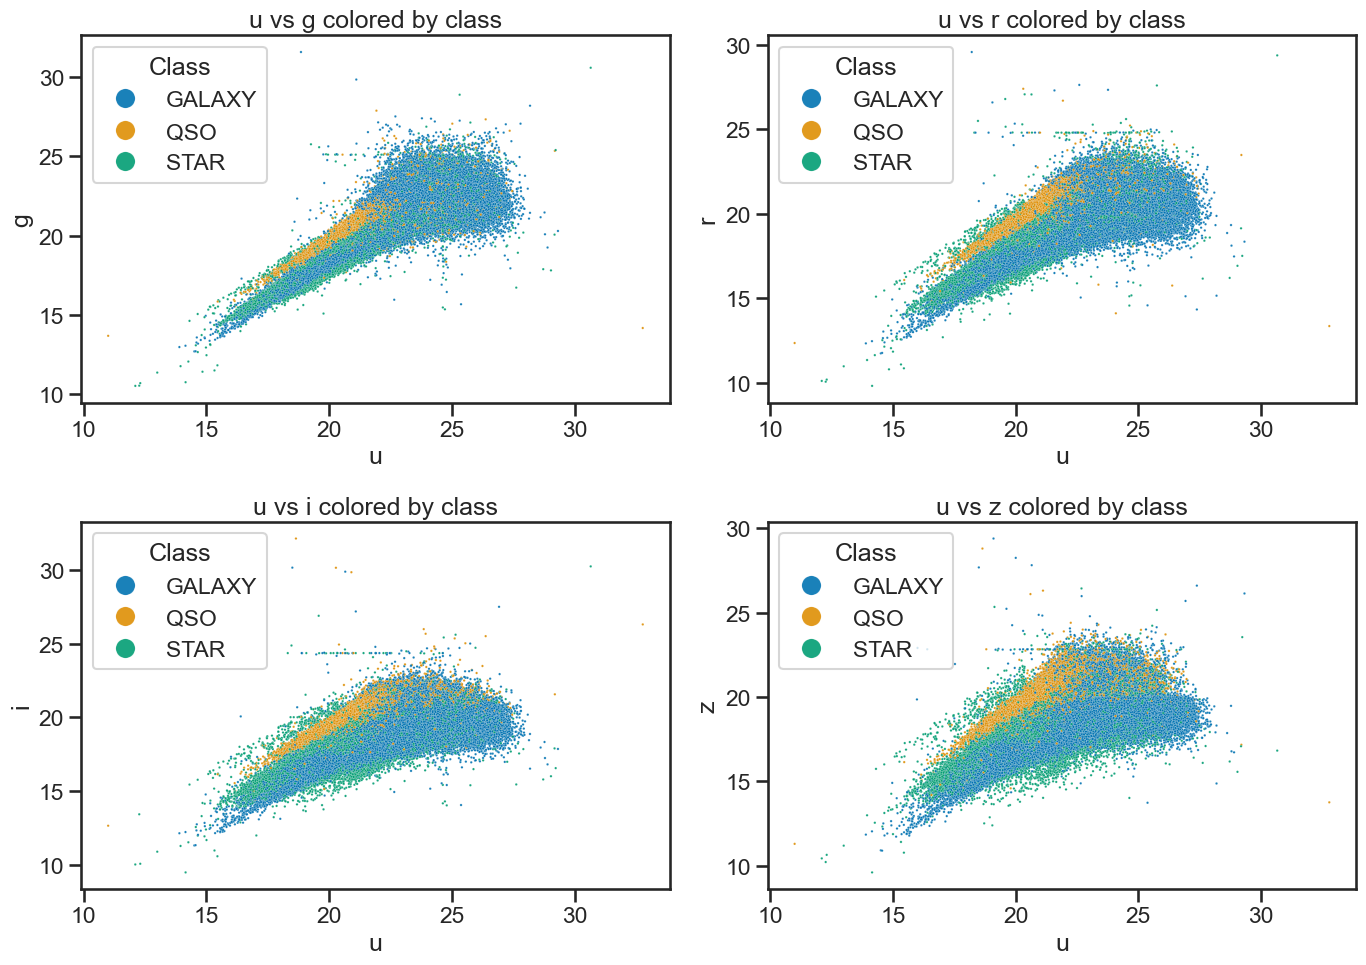

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# u vs g
sns.scatterplot(x='u', y='g', hue='class', data=df_stellar, ax=axes[0, 0], alpha=0.9, s=3)
axes[0, 0].set_xlabel('u')
axes[0, 0].set_ylabel('g')
axes[0, 0].set_title('u vs g colored by class')
axes[0, 0].legend(title='Class', loc='upper left', markerscale=8)

# u vs r
sns.scatterplot(x='u', y='r', hue='class', data=df_stellar, ax=axes[0, 1], alpha=0.9, s=3)
axes[0, 1].set_xlabel('u')
axes[0, 1].set_ylabel('r')
axes[0, 1].set_title('u vs r colored by class')
axes[0, 1].legend(title='Class', loc='upper left', markerscale=8)

# u vs i
sns.scatterplot(x='u', y='i', hue='class', data=df_stellar, ax=axes[1, 0], alpha=0.9, s=3)
axes[1, 0].set_xlabel('u')
axes[1, 0].set_ylabel('i')
axes[1, 0].set_title('u vs i colored by class')
axes[1, 0].legend(title='Class', loc='upper left', markerscale=8)

# u vs z
sns.scatterplot(x='u', y='z', hue='class', data=df_stellar, ax=axes[1, 1], alpha=0.9, s=3)
axes[1, 1].set_xlabel('u')
axes[1, 1].set_ylabel('z')
axes[1, 1].set_title('u vs z colored by class')
axes[1, 1].legend(title='Class', loc='upper left', markerscale=8)

plt.tight_layout()
plt.savefig('figures/stellar_color_diagrams.png', dpi=300)
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
# Define the features and target variable
X = df_stellar[['u', 'g', 'r', 'i']]
y = df_stellar['z']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# Create a linear regression model
model = LinearRegression()

# Scale the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test sets
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# Fit the model to the training data
model.fit(X_train, y_train)

LinearRegression()

In [7]:
# Make predictions on the test set
y_pred = model.predict(X_test)

/Users/caballero/repos/teaching/MSU_REU_ML_course/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/caballero/repos/teaching/MSU_REU_ML_course/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/caballero/repos/teaching/MSU_REU_ML_course/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [8]:
def evaluate_regression(y_true, y_pred, label=""):
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    if label:
        print(f"Results for {label}:")
    print(f"  Mean Squared Error: {mse:.4f}")
    print(f"  R-squared: {r2:.4f}")
    return mse, r2

# Evaluate the model
evaluate_regression(y_test, y_pred, label="Linear Regression (u, g, r, i)")

Results for Linear Regression (u, g, r, i):
  Mean Squared Error: 0.1645
  R-squared: 0.9470


(0.16451171809284193, 0.9470343482118454)

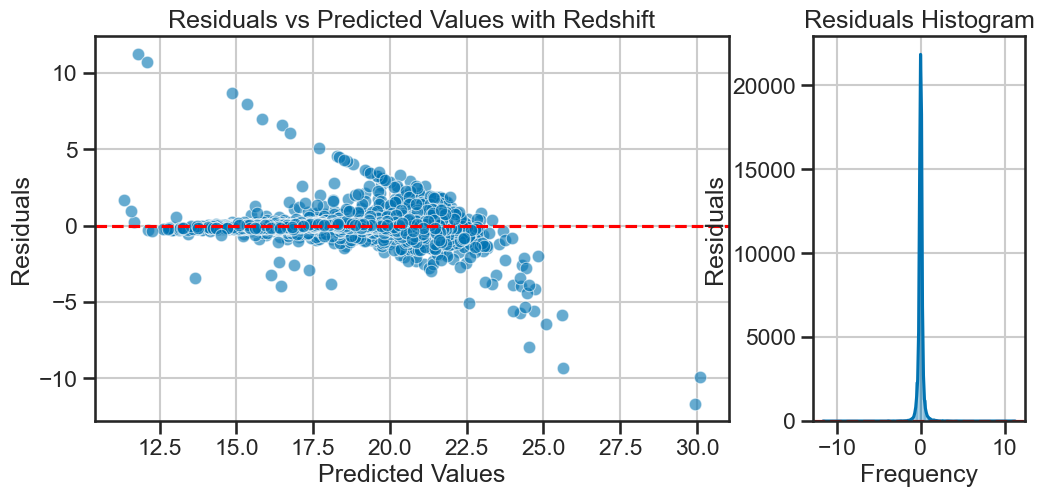

In [9]:
def plot_residuals_with_hist(y_true, y_pred, title="Residuals vs Predicted Values", filename=None, axis=None):

    residuals = y_true - y_pred

    if axis is not None and not (isinstance(axis, (list, tuple)) and len(axis) == 2):
        raise ValueError("axis must be a list or tuple of two matplotlib axes (for scatter and histogram).")

    if axis is None:
        fig, axis = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios': [3, 1]})

    # Scatter plot: residuals vs predicted
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.6, ax=axis[0])
    axis[0].axhline(0, color='red', linestyle='--')
    axis[0].set_xlabel('Predicted Values')
    axis[0].set_ylabel('Residuals')
    axis[0].set_title(title)
    axis[0].grid(True)

    # Horizontal histogram: residuals on y, count on x
    sns.histplot(residuals, bins=50, kde=True, ax=axis[1])
    axis[1].axhline(0, color='red', linestyle='--')
    axis[1].set_ylabel('Residuals')
    axis[1].set_xlabel('Frequency')
    axis[1].set_title('Residuals Histogram')
    axis[1].grid(True)

    if filename and axis is None:
        plt.tight_layout()
        plt.savefig(filename, dpi=300)
    if axis is None:
        plt.tight_layout()
        plt.show()

plot_residuals_with_hist(y_test, y_pred, title='Residuals vs Predicted Values with Redshift')

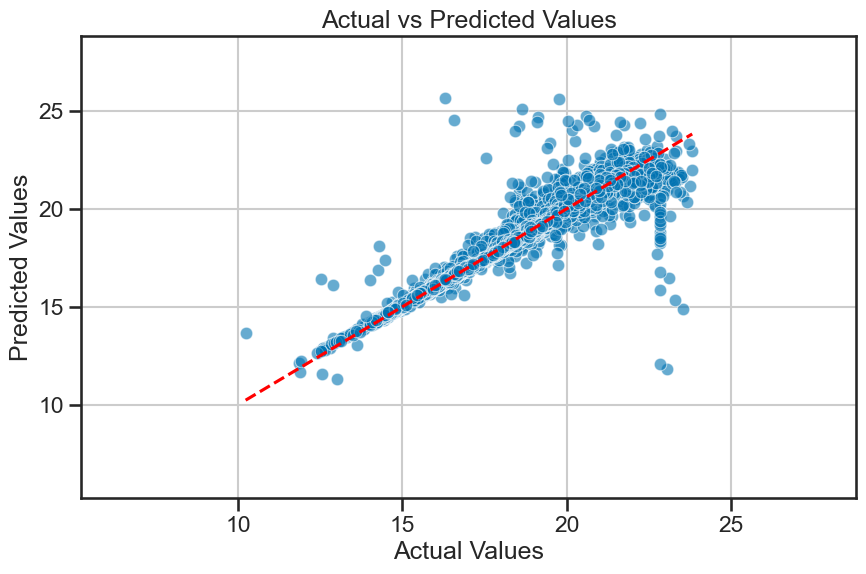

In [10]:
def plot_actual_vs_predicted(y_true, y_pred, title='Actual vs Predicted Values', filename=None,axis=None, delta=5):
    if axis is None:
        fig,axis = plt.subplots(figsize=(10, 6))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.6, ax=axis)
    axis.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], color='red', linestyle='--')
    axis.set_xlim(y_true.min()-delta, y_true.max()+delta)
    axis.set_ylim(y_true.min()-delta, y_true.max()+delta)
    axis.set_xlabel('Actual Values')
    axis.set_ylabel('Predicted Values')
    axis.set_title(title)
    axis.grid(True)
    
    if filename and axis is None:
        plt.tight_layout()
        plt.savefig(filename, dpi=300)
    if axis is None:
        plt.tight_layout()
        plt.show()

# Plot actual vs predicted values
plot_actual_vs_predicted(y_test, y_pred, filename='figures/stellar_regression_results.png')

<Figure size 1000x600 with 0 Axes>

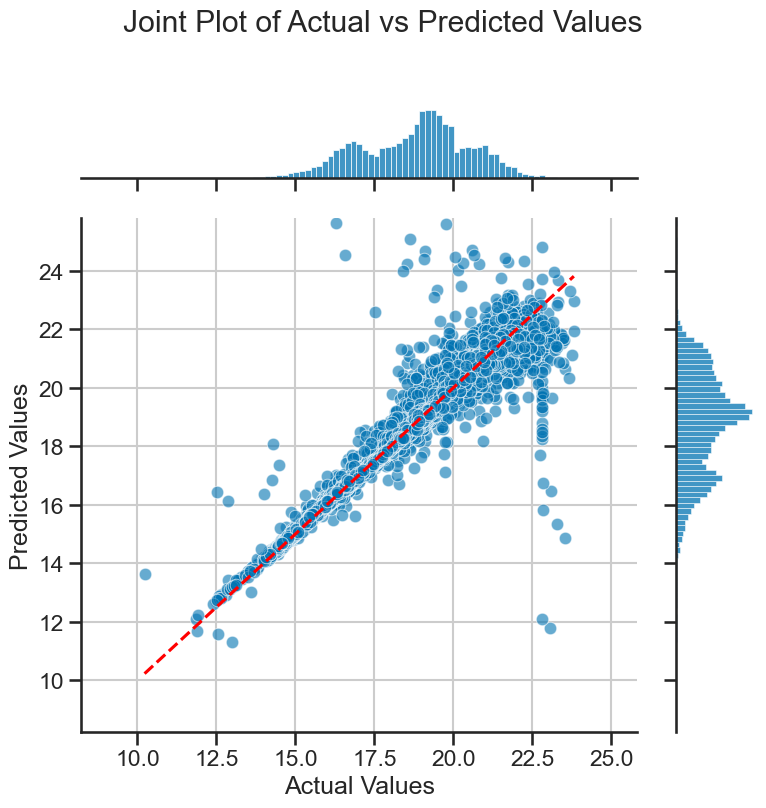

In [11]:
def plot_joint_actual_vs_predicted(y_true, y_pred, filename=None, delta=2):
    plt.figure(figsize=(10, 6))
    sns.jointplot(x=y_true, y=y_pred, kind='scatter', alpha=0.6, height=8)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], color='red', linestyle='--')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.xlim(y_true.min()-delta, y_true.max()+delta)
    plt.ylim(y_true.min()-delta, y_true.max()+delta)
    plt.suptitle('Joint Plot of Actual vs Predicted Values', y=1.02)
    plt.grid(True)
    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=300)
    plt.show()

plot_joint_actual_vs_predicted(y_test, y_pred, filename='figures/stellar_joint_plot.png')

In [12]:
intercept = model.intercept_ #beta0
coefficients = model.coef_ #beta1, beta2, beta3, beta4
features = X.columns.tolist() # feature names

print(intercept)
print(coefficients)
print(features)

18.769633356579455
[ 0.01160737 -0.43194222  0.2577279   1.82800805]
['u', 'g', 'r', 'i']


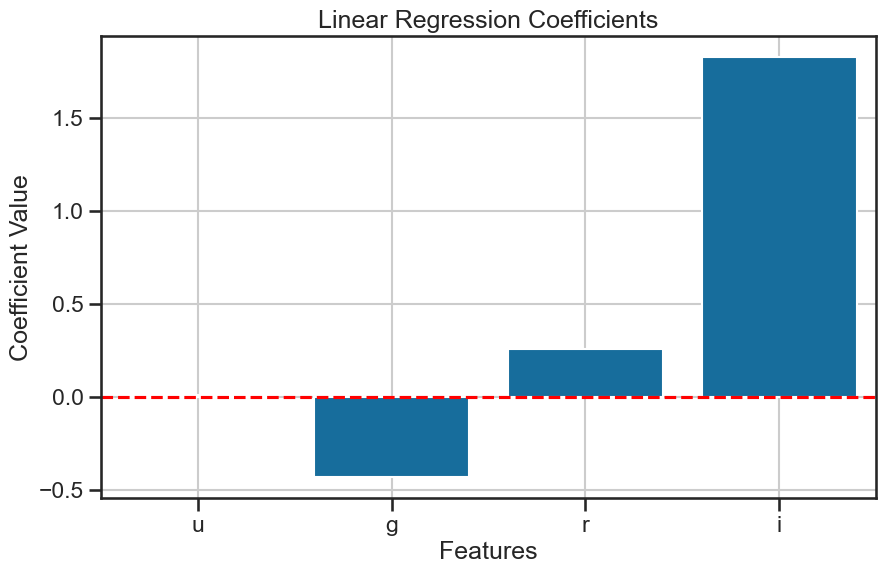

In [13]:
def plot_coefficients(model, feature_names, title='Model Coefficients', filename=None, axis=None):
    coefficients = model.coef_
    if axis is None:
        fig, axis = plt.subplots(figsize=(10, 6))
    sns.barplot(x=feature_names, y=coefficients, ax=axis)
    axis.set_xlabel('Features')
    axis.set_ylabel('Coefficient Value')
    axis.set_title(title)
    axis.axhline(0, color='red', linestyle='--')
    axis.grid(True)
    if filename and axis is None:
        plt.tight_layout()
        plt.savefig(filename, dpi=300)
    if axis is None:
        plt.tight_layout()
        plt.show()
    
plot_coefficients(model, X.columns, title='Linear Regression Coefficients', filename='figures/stellar_regression_coefficients.png')

In [14]:
evaluate_regression(y_test, y_pred, label="Linear Regression (u, g, r, i)")

Results for Linear Regression (u, g, r, i):
  Mean Squared Error: 0.1645
  R-squared: 0.9470


(0.16451171809284193, 0.9470343482118454)

In [15]:
coefficients = model.coef_ #beta1, beta2, beta3, beta4
features = X.columns.tolist() # feature names

# sort features by their coefficients in descending order
sorted_indices = np.argsort(np.abs(coefficients))[::-1] 

# sort features
sorted_features = [features[i] for i in sorted_indices]

# print sorted features
print(sorted_features)

['i', 'g', 'r', 'u']


In [16]:
def get_sorted_features_by_coef(model, X):
    """
    Returns feature names sorted by the absolute value of their coefficients (descending).
    """
    coefficients = model.coef_
    features = X.columns.tolist()
    sorted_indices = np.argsort(np.abs(coefficients))[::-1]
    sorted_features = [features[i] for i in sorted_indices]
    print(sorted_features)
    return sorted_features

sorted_features = get_sorted_features_by_coef(model, X)

['i', 'g', 'r', 'u']


/Users/caballero/repos/teaching/MSU_REU_ML_course/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/caballero/repos/teaching/MSU_REU_ML_course/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/caballero/repos/teaching/MSU_REU_ML_course/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/caballero/repos/teaching/MSU_REU_ML_course/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/caballero/repos/teaching/MSU_REU_ML_course/.venv/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul


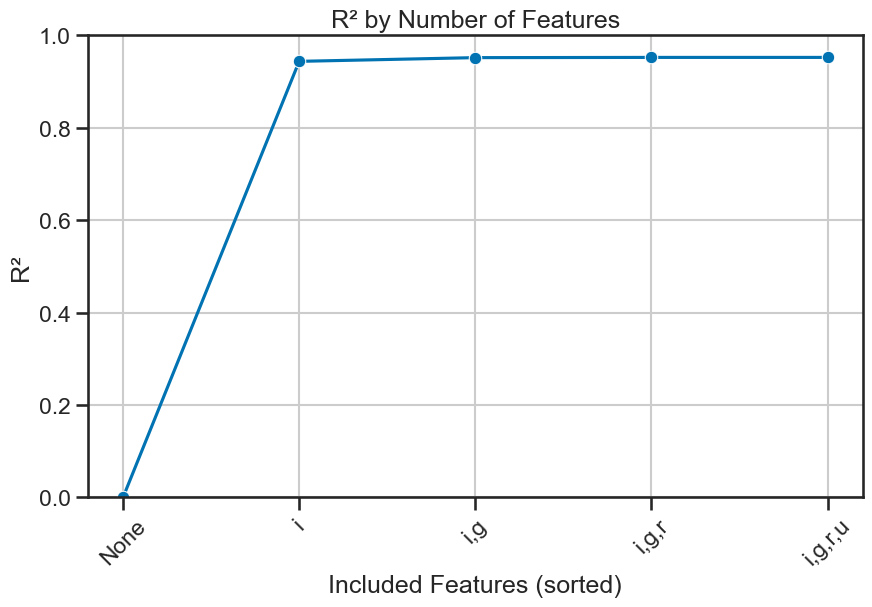

In [17]:
def plot_explained_variance(model, X, y, sorted_features, title='Explained Variance by Number of Features', filename=None, axis=None):
    explained_variance = [0]  # Start with 0 for no variables
    feature_labels = ['None']
    for i in range(1, len(sorted_features) + 1):
        selected = sorted_features[:i]
        model.fit(X[selected], y)
        explained_variance.append(model.score(X[selected], y))
        feature_labels.append(','.join(selected))
    
    if axis is None:
        fig, axis = plt.subplots(figsize=(10, 6))
    sns.lineplot(x=range(len(feature_labels)), y=explained_variance, marker='o', ax=axis)
    axis.set_xticks(range(len(feature_labels)))
    axis.set_xticklabels(feature_labels, rotation=45)
    axis.set_xlabel('Included Features (sorted)')
    axis.set_ylabel('R²')
    axis.set_title(title)
    axis.set_ylim(0, 1)
    axis.grid(True)
    if filename and axis is None:
        plt.tight_layout()
        plt.savefig(filename, dpi=300)
    if axis is None:
        plt.tight_layout()
        plt.show()

# Plot the explained variance ratio using sorted_features
plot_explained_variance(model, X, y, sorted_features, title='R² by Number of Features', filename='figures/stellar_explained_variance_sorted.png')

In [18]:
### your code here

In [19]:
### your code here

In [20]:
### your code here

In [21]:
### your code here

In [22]:
### your code here

In [23]:
### your code here

In [24]:
### your code here